<a href="https://colab.research.google.com/github/MiguelFigueroa02/MCPI_Student_Repo/blob/main/courses/1-Semester/fundamentals%20of%20statistics/Projects/002_3_Figueroa_Miguel_Probabilidad_distribuciones_y_muestreo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p align="center">
  <img src="https://raw.githubusercontent.com/MiguelFigueroa02/MCPI_Student_Repo/refs/heads/main/images/logo.png"
       width="30%">
</p>

#Fundamentos de Estadística
---
**Profesor:** Dr. Daniel de La Rosa Gómez\
**Estudiante:** Miguel Figueroa Aguilar


### Video en LOOM explicando el ejercicio:

https://www.loom.com/share/da5b5b265d8c455493620a644f0f3e90

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import plotly.express as px

In [ ]:
#Establecemos un formato adecuado de visualización de los dataframe que extraigamos
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth',None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [ ]:
# El dataset se extrae de la plataforma de kaggle y se sube a un repositorio personal de github
url = 'https://raw.githubusercontent.com/MiguelFigueroa02/MCPI_Student_Repo/refs/heads/main/courses/1-Semester/fundamentals%20of%20statistics/Projects/Data/lung_cancer_dataset.csv'

response = requests.get(url)
if response.status_code == 200:
  print('Se accedió a dataset con éxito')
  df = pd.read_csv(url)

Se accedió a dataset con éxito


In [ ]:
# Verificamos de manera inicial la información
df.head()

,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Age_Group,Gender,Smoking_Status,Cigarettes_Per_Day,Years_Smoking,Pack_Years,Secondhand_Smoke,Family_History,Occupational_Hazard,Air_Pollution_Exposure,Alcohol_Use,BMI,BMI_Category,Exercise_Frequency,Chronic_Lung_Disease,Asbestos_Exposure,Radon_Exposure,Previous_Cancer_History,Risk_Factor_Count,Genetic_Mutation,Coughing,Shortness_of_Breath,Chest_Pain,Coughing_Blood,Fatigue,Weight_Loss,Wheezing,Recurrent_Infections,Swallowing_Difficulty,Finger_Clubbing,Symptom_Count,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived
0,LC-0001,2020,2020-11-04,Western Pacific,China,46,40-49,Female,Current Smoker,28,28,39.20,Yes,No,No,Moderate,No Alcohol,29.60,Overweight,Low,Yes,No,No,No,2,No Mutation,Yes,Yes,Yes,No,No,Yes,No,No,Yes,No,5,NSCLC,Adenocarcinoma,Stage IV,6.40,Yes,MRI,Chemo + Radiation,4,No
1,LC-0002,2021,2021-12-09,Americas,Mexico,71,70-79,Male,Former Smoker,5,34,8.50,Yes,No,No,High,Heavy,31.30,Obese,Moderate,No,No,No,Yes,3,KRAS,Yes,Yes,No,No,Yes,No,Yes,No,Yes,No,5,NSCLC,Adenocarcinoma,Stage I,2.60,No,Biopsy,Surgery + Chemotherapy,76,Yes
2,LC-0003,2017,2017-04-05,Western Pacific,Japan,53,50-59,Female,Never Smoked,0,0,0.00,Yes,No,No,High,Moderate,25.80,Overweight,Low,No,No,No,No,2,KRAS,No,No,Yes,Yes,Yes,No,No,No,No,No,3,NSCLC,Squamous Cell,Stage I,2.90,No,LDCT Screening,Surgery,69,No
3,LC-0004,2018,2018-11-24,Western Pacific,Singapore,55,50-59,Male,Current Smoker,21,34,35.70,No,Yes,No,Moderate,No Alcohol,25.30,Overweight,Low,Yes,No,No,No,2,No Mutation,Yes,No,No,Yes,Yes,Yes,Yes,Yes,No,No,6,NSCLC,Adenocarcinoma,Stage IV,7.00,Yes,CT Scan,Chemotherapy,9,No
4,LC-0005,2024,2024-02-19,Western Pacific,Malaysia,54,50-59,Male,Never Smoked,0,0,0.00,No,No,Yes,High,No Alcohol,32.00,Obese,Low,Yes,No,No,Yes,4,KRAS,Yes,No,Yes,No,Yes,No,Yes,No,Yes,No,5,NSCLC,Adenocarcinoma,Stage III,5.80,No,Bronchoscopy,Immunotherapy,5,Yes


In [ ]:
df.Diagnosis_Year = pd.to_datetime(df.Diagnosis_Year)
df.Diagnosis_Date = pd.to_datetime(df.Diagnosis_Date)

In [ ]:
print(f'La cantidad de variables son {len(df.columns)}')
print(f'La cantidad de observaciones son {df.shape[0]}')

La cantidad de variables son 46
La cantidad de observaciones son 2000


In [ ]:
categoricas = [col for col in df.columns if df[col].dtype == 'object']

In [ ]:
# Verificando cada una de las variables determinamos que las siguiente son del tipo ordinal
ordinales = ['Age_Group','Smoking_Status','Air_Pollution_Exposure', 'Alcohol_Use','BMI_Category','Exercise_Frequency','Cancer_Stage']

In [ ]:
nominales = [categorica for categorica in categoricas if categorica not in ordinales]

In [ ]:
cuant_disc = []
cuant_cont = []

for col in df.columns:
  var_type = df[col].dtype
  if var_type == 'int64':
    cuant_disc.append(col)
  elif var_type == 'float64' or var_type=='<M8[ns]':
    cuant_cont.append(col)

In [ ]:
print('Las variables Cuantitativas Discretas son:\n-'+',\n-'.join(x.strip() for x in cuant_disc))

Las variables Cuantitativas Discretas son:
-Diagnosis_Year,
-Age,
-Cigarettes_Per_Day,
-Years_Smoking,
-Risk_Factor_Count,
-Symptom_Count,
-Survival_Months


In [ ]:
print('Las variables Cuantitativas Continuas son:\n-'+',\n-'.join(x.strip() for x in cuant_cont))

Las variables Cuantitativas Continuas son:
-Pack_Years,
-BMI,
-Tumor_Size_cm


In [ ]:
print('Las variables Categóricas Ordinales son:\n-'+',\n-'.join(x.strip() for x in ordinales))

Las variables Categóricas Ordinales son:
-Age_Group,
-Smoking_Status,
-Air_Pollution_Exposure,
-Alcohol_Use,
-BMI_Category,
-Exercise_Frequency,
-Cancer_Stage


In [ ]:
df[ordinales].describe()

,Age_Group,Smoking_Status,Air_Pollution_Exposure,Alcohol_Use,BMI_Category,Exercise_Frequency,Cancer_Stage
count,2000,2000,2000,2000,2000,2000,2000
unique,6,3,3,3,4,3,4
top,50-59,Never Smoked,Moderate,Moderate,Overweight,Low,Stage I
freq,657,1311,766,811,876,772,577


In [ ]:
for ordinal in ordinales:
  print(f'Los valores únicos en la variable {ordinal} son:', ", ".join(f'{descr}' for descr in df[ordinal].unique()))
  print('--'*50)

Los valores únicos en la variable Age_Group son: 40-49, 70-79, 50-59, 80-89, 60-69, 30-39
----------------------------------------------------------------------------------------------------
Los valores únicos en la variable Smoking_Status son: Current Smoker, Former Smoker, Never Smoked
----------------------------------------------------------------------------------------------------
Los valores únicos en la variable Air_Pollution_Exposure son: Moderate, High, Low
----------------------------------------------------------------------------------------------------
Los valores únicos en la variable Alcohol_Use son: No Alcohol, Heavy, Moderate
----------------------------------------------------------------------------------------------------
Los valores únicos en la variable BMI_Category son: Overweight, Obese, Normal, Underweight
----------------------------------------------------------------------------------------------------
Los valores únicos en la variable Exercise_Frequency so

In [ ]:
print('Las variables Categóricas Nominales son:\n-'+',\n-'.join(x.strip() for x in nominales))

Las variables Categóricas Nominales son:
-Patient_ID,
-Diagnosis_Date,
-WHO_Region,
-Country,
-Gender,
-Secondhand_Smoke,
-Family_History,
-Occupational_Hazard,
-Chronic_Lung_Disease,
-Asbestos_Exposure,
-Radon_Exposure,
-Previous_Cancer_History,
-Genetic_Mutation,
-Coughing,
-Shortness_of_Breath,
-Chest_Pain,
-Coughing_Blood,
-Fatigue,
-Weight_Loss,
-Wheezing,
-Recurrent_Infections,
-Swallowing_Difficulty,
-Finger_Clubbing,
-Cancer_Type,
-NSCLC_Subtype,
-Metastasis,
-Diagnosis_Method,
-Treatment,
-Survived


In [ ]:
df[nominales].describe()

,Patient_ID,Diagnosis_Date,WHO_Region,Country,Gender,Secondhand_Smoke,Family_History,Occupational_Hazard,Chronic_Lung_Disease,Asbestos_Exposure,Radon_Exposure,Previous_Cancer_History,Genetic_Mutation,Coughing,Shortness_of_Breath,Chest_Pain,Coughing_Blood,Fatigue,Weight_Loss,Wheezing,Recurrent_Infections,Swallowing_Difficulty,Finger_Clubbing,Cancer_Type,NSCLC_Subtype,Metastasis,Diagnosis_Method,Treatment,Survived
count,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000
unique,2000,1520,6,60,2,2,2,2,2,2,2,2,10,2,2,2,2,2,2,2,2,2,2,2,4,2,7,8,2
top,LC-1984,2026-07-07,Western Pacific,Japan,Male,No,No,No,No,No,No,No,No Mutation,No,No,No,No,Yes,No,No,No,No,No,NSCLC,Adenocarcinoma,No,CT Scan,Surgery,No
freq,1,8,631,74,1248,1050,1483,1572,1624,1886,1847,1881,729,1024,1134,1292,1544,1323,1333,1448,1403,1717,1752,1771,1109,1441,590,410,1244


In [ ]:
def cuantitativo(df,columna):
  print(f'Se selecciona la variable cuantitativa {columna}:\n')
  print('--'*25)

  col = df[columna]
  q1 = col.quantile(0.25)
  print(f'- Resultados del primer cuartil (Q1):  {q1}\n')
  q3 = col.quantile(0.75)
  print(f'- Resultados del tercer cuartil (Q3):  {q3}\n')
  iqr = q3 - q1
  print(f'- Rango Intercuartil (IQR):  {iqr}')
  print('--'*25)

  lim_inf = q1 - (1.5 * iqr)
  atipicos_li = df[(df[columna] < lim_inf)][['Patient_ID',columna, 'Age_Group','Country','Cancer_Type','Survived']].set_index(['Patient_ID'])
  print(f'Límite inferior conforme a regla del rango IQR (1.5 veces IQR):  {lim_inf:.2f}')
  cant_atip_li = len(atipicos_li)
  print(f'Cantidad de resultados atípicos debajo de rango 1.5 veces IQR: {cant_atip_li}')
  if cant_atip_li > 0:
    print(atipicos_li.sort_values(columna,ascending=False).to_markdown())
  print('--'*25)

  mediana = col.median()
  print(f'Valor de mediana: {mediana}')
  media = col.mean()
  print(f'Valor de media: {media:.2f}')
  dev_est = col.std()
  print(f'Desviación Estándar: {dev_est:.2f}')
  print('--'*25)

  lim_sup = q3 + (1.5 * iqr)
  atipicos_su = df[(df[columna] > lim_sup)][['Patient_ID',columna, 'Age_Group','Country','Cancer_Type','Survived']].set_index(['Patient_ID'])
  print(f'Límite superior conforme a regla del rango IQR (1.5 veces IQR):  {lim_sup:.2f}')
  cant_atip_su = len(atipicos_su)
  print(f'Cantidad de resultados atípicos superiores a rango 1.5 veces IQR: {cant_atip_su}')
  if cant_atip_su > 0:
    print(atipicos_su.sort_values(columna,ascending=True).to_markdown())

# Probabilidad, distribuciones y Muestreo

### Frecuencias en una variable categórica

Para optimizar el proceso, generamos una función

In [ ]:
def categorica(columna):
  frecuencias = df[columna].value_counts(dropna=False).sort_values(ascending=False)
  proporciones = df[columna].value_counts(normalize= True, dropna=False).sort_values(ascending=False)
  proporciones = proporciones.apply(lambda x: f'{x:.2%}')

  tabla_frecuencias = pd.DataFrame({
      'frecuencia':frecuencias,
      'proporciones(%)':proporciones
  })

  return tabla_frecuencias

A manera de prueba inicial, elegimos la variable `Treatment`

In [ ]:
proporcion_categorica= categorica('Treatment')

In [ ]:
# proporcion_categorica.to_markdown()

| Treatment              |   frecuencia | proporciones(%)   |
|:-----------------------|:------------:|:-----------------:|
| Surgery                |          410 | 20.50%            |
| Chemotherapy           |          341 | 17.05%            |
| Surgery + Chemotherapy |          311 | 15.55%            |
| Immunotherapy          |          273 | 13.65%            |
| Targeted Therapy       |          217 | 10.85%            |
| Radiotherapy           |          205 | 10.25%            |
| Chemo + Radiation      |          192 | 9.60%             |
| Palliative Care        |           51 | 2.55%             |

---
1.¿Cuál es la categoría más frecuente?
> El tratamiento de cirugía `Surgery` es la más frecuente, la cuál representa 410 del total de los 2000 registros.

2. ¿Cuál es su proporción?

> Representa el 20.50% del total.

3. ¿Existen datos faltantes?

> No, todos los pacientes cuentan con registros en esta variable.

4. ¿Qué porcentaje representan los datos faltantes?

> 0%

5. Para la pregunta que estás realizando, ¿deben los valores faltantes formar parte del denominador?
Justifica.

> En caso del registro de tratamiento para el cáncer, podríamos considerar un dato faltante como el de un paciente que aún no ha recibido tratamiento, por lo que podríamos como una categoría independiente a los demás registros. Por lo que para este caso no sería convieniente eliminarlo en caso de presentarse.

### Define un evento en tu base
---


- Seleccionamos el evento `Surgery`, que representa a los pancientes que fueron tratados con tratamiento de cirugía.

In [ ]:
def evento_base(variable, evento):
  col_cat = variable
  valor_evento = evento
  datos_cat = df[col_cat].dropna()

  p_base = (datos_cat==valor_evento).mean()

  print("Proporciónen la base completa: ", p_base)
  print(f'Dentro de las observaciones válidas de la base analizada, \nla proporción de {variable} fue {p_base:.2%}')

In [ ]:
evento_base('Treatment','Surgery')

Proporciónen la base completa:  0.205
Dentro de las observaciones válidas de la base analizada, 
la proporción de Treatment fue 20.50%


1. ¿Puedes interpretar automáticamente esta proporción como la probabilidad correspondiente a
toda una población externa? Explica.
> No, porque el dataset está enfocado en pacientes de determinados países. Necesitaríamos conocer datos de las regiones faltantes de la WHO

2. ¿Qué información adicional necesitarías para hacer una afirmación poblacional?
> Evaluar de igual manera pacientes que no han recibido tratamiento para determinar la proporción  de estos o bien, considerar grupos adicionales de países con diferentes niveles económicos.

### Comparación de proporciones entre muestras
---

In [ ]:
def proporciones_mtras(variable,evento):
  resultados = []
  col_cat = variable
  valor_evento = evento
  datos_cat = df[col_cat].dropna()

  n_muestra = min(50, len(datos_cat))

  for semilla in [10,20,30]:
    muestra = datos_cat.sample(
        n=n_muestra,
        replace=False,
        random_state=semilla
    )

    p_muestra= (
        muestra==valor_evento
    ).mean()

    resultados.append({
        'muestra':semilla,
        'n':n_muestra,
        'proporción':p_muestra
    })

  resultados_df= pd.DataFrame(resultados)
  resultados_df.set_index('muestra',drop=True, inplace=True)
  return resultados_df


In [ ]:
mtras_treatment= proporciones_mtras('Treatment','Surgery')

In [ ]:
# mtras_treatment.to_markdown()

|   muestra |   n |   proporción |
|:---------:|:---:|:------------:|
|        10 |  50 |         0.28 |
|        20 |  50 |         0.26 |
|        30 |  50 |         0.22 |
---


1. ¿Las tres proporciones son idénticas?
> No, varían cada una de acuerdo a la semilla. Aunque son cercanas (0.6 de diferencia entre la mayor y menor), no son iguales.

2. ¿Cuál quedó más cerca de la proporción de la base completa?
> La última toma de muestra, con la semilla de 30 (0.22), quedó más cercana a la de la proporción de los 2000 registros (0.205)

3. ¿El hecho de que una proporción muestral sea diferente del valor de la base completa significa que el procedimiento está mal?
> No, de hecho es esperada cierta variación puesto que es un estimador del valor real. Por ello los 3 muestreos son cercanos pero no iguales al valor poblacional. Dicha diferencia, en este caso, es debida a la aleatoriedad propiciada a partir de la semilla elegida.

4. ¿Qué concepto estadístico explica estas diferencias?
> La ley de los grandes números, en donde se indica que los valores de los muestreos tienden a estabilizarse alrededor del valor estadístico real.

## Estadísticos poblacionales y muestrales

Seleccionamos la variable `Age`

In [ ]:
def estadisticos_poblacional(variable):
  col_num = variable
  x = pd.to_numeric(
      df[col_num],
      errors='coerce'
  ).dropna()

  N = len(x)

  mu = x.mean()
  mediana = x.median()
  sigma = x.std(ddof=0)

  print("N=", N)
  print("Media de la base completa =", mu)
  print("Mediana de la base completa =", mediana)
  print(
      "Desviación Estándar Poblacional =",
      sigma
  )

In [ ]:
estadisticos_poblacional('Age')

N= 2000
Media de la base completa = 60.749
Mediana de la base completa = 60.0
Desviación Estándar Poblacional = 10.334650405311255


In [ ]:
def muestra_numerico(variable, semilla):
  col_num = variable
  x = pd.to_numeric(
      df[col_num],
      errors='coerce'
  ).dropna()

  N = len(x)

  mu = x.mean()
  mediana = x.median()
  sigma = x.std(ddof=0)

  n=min(50,N)
  muestra = x.sample(
      n=n,
      replace=False,
      random_state=semilla
  )
  x_barra = muestra.mean()
  mediana_muestra = muestra.median()
  s = muestra.std(ddof=1)

  print("Media muestral =", x_barra)
  print(
      "Mediana muestral =",
      mediana_muestra
  )
  print(
      "Desviación estándar muestral =",
      s
  )

  df_comparacion= pd.DataFrame({
      'Estadístico':['Media','Mediana','Desviación Estándar'],
      'Base Completa':[mu,mediana,sigma],
      'Muestra':[x_barra,mediana_muestra,s]
  })
  df_comparacion.set_index('Estadístico',drop=True, inplace=True)
  return df_comparacion


In [ ]:
edad_muestra = muestra_numerico('Age',2026)

Media muestral = 62.28
Mediana muestral = 61.5
Desviación estándar muestral = 10.730540051456794


In [ ]:
# edad_muestra.to_markdown()

| Estadístico         |   Base Completa |   Muestra |
|:--------------------|:---------------:|:---------:|
| Media               |         60.749  |   62.28   |
| Mediana             |         60      |   61.5    |
| Desviación Estándar |         10.3347 |   10.7305 |

---
1. ¿La media muestral coincide exactamente con μ?
> No, tal como se observa en la tabla anterior es cercana pero mayor al valor considerado como poblacional.

2. ¿La mediana coincide exactamente?
> Tampoco. Esta es mayor a la mediana de la base completa.

3. ¿La desviación estándar coincide exactamente?
> En menor medida aumento con respecto al valor de la base completa

4. ¿Cuál de los tres estadísticos cambió más en términos relativos?
> El valor de la media de la muestra presenta un valor mayor con respecto al obtenido en la variación de los otros valores.

5. ¿Estas diferencias implican necesariamente un error?
> No, son producto de la aleatoriedad al obtener la muestra.

6. ¿Qué esperas que ocurra con la media muestral si aumenta el tamaño de la muestra?
> Que varíe en torno al valor poblacional y tienda a acercarse al valor real conforme aumente dicho tamaño muestral.



## Generar muchas muestras

In [ ]:
def boxplot(df,columna, unidades, title_labels='', bins='fd', kde=False, color='#1D7874',median_color='#AC3931',mode_color='#EAC435',media_color='#40376E'):
  col = df[columna]
  plt.figure(figsize=(9, 5))
  plt.style.use("dark_background")
  ax = plt.axes()
  ax.set_facecolor('#080705')
  boxprops = dict(facecolor="#2A7B7C", edgecolor="white", linewidth=1.5)
  whiskerprops = dict(color="white", linewidth=2)
  capprops = dict(color="white", linewidth=2)
  medianprops = dict(color="white", linewidth=2.5)
  meanprops = dict(
      marker="o", markeredgecolor="black", markerfacecolor="white", markersize=8
  )
  flierprops = dict(
      marker="o", markerfacecolor="none", markeredgecolor="white", alpha=0.6
  )

  sns.boxplot(data=df, x=columna, orient='h', ax=ax,
              showmeans=True,meanprops=meanprops,medianprops=medianprops,
              whiskerprops=whiskerprops,capprops=capprops,boxprops=boxprops,
              flierprops=flierprops
              )
  plt.axvline(col.median(), color=median_color, linewidth=2, label=f"mediana = {col.median():.2f}")
  plt.axvline(col.mean(),   color=media_color, linewidth=2, label=f"media = {col.mean():.2f}")
  plt.axvline(col.mode()[0],   color=mode_color, linewidth=2, label=f"moda = {col.mode()[0]:.2f}")
  plt.title(f"Histograma para columna {columna}. {title_labels}", fontsize=14)
  plt.xlabel(f'{columna}',fontsize=10)
  plt.ylabel(unidades,fontsize=10)
  ax.spines[['top','right','left','bottom']].set_visible(False)
  ax.set_axisbelow(True)
  ax.yaxis.grid(color='white', linestyle='--', linewidth=0.5)
  plt.legend(loc='upper right')

  plt.show()

In [ ]:
def histograma(df,columna, unidades, title_labels='', bins='fd', kde=False, color='#1D7874',median_color='#AC3931',mode_color='#EAC435',media_color='#40376E'):
  col = df[columna]
  plt.figure(figsize=(9, 5))
  plt.style.use("dark_background")
  ax = plt.axes()
  ax.set_facecolor('#080705')
  sns.histplot(df[columna].dropna(), bins=bins, color=color, edgecolor="white",kde=kde)
  plt.axvline(col.median(), color=median_color, linewidth=2, label=f"mediana = {col.median():.2f}")
  plt.axvline(col.mean(),   color=media_color, linewidth=2, label=f"media = {col.mean():.2f}")
  plt.axvline(col.mode()[0],   color=mode_color, linewidth=2, label=f"moda = {col.mode()[0]:.2f}")
  plt.title(f"Histograma para columna {columna}. {title_labels}", fontsize=14)
  plt.xlabel(unidades,fontsize=10)
  plt.ylabel('Frecuencia',fontsize=10)
  plt.legend()
  ax.spines[['top','right']].set_visible(False)
  plt.show()

In [ ]:
from IPython.core.pylabtools import figsize
def muestras_numericas(variable, semilla):
  col_num = variable
  x = pd.to_numeric(
      df[col_num],
      errors='coerce'
  ).dropna()

  N = len(x)

  mu = x.mean()
  mediana = x.median()
  sigma = x.std(ddof=0)

  rng = np.random.default_rng(semilla)

  tamanios = [10,30,100]

  B = 2000

  medias_por_n = {}
  resumen = []

  for n in tamanios:
    medias = np.array([
        rng.choice(
            x,
            size= n,
            replace=True
        ).mean()
        for _ in range(B)
    ])

    medias_por_n[n]=medias

    resumen.append({
        'n':n,
        'media_de_medias':medias.mean(),
        'sd_empirica_medias':medias.std(ddof=1),
        'SE_teórico':sigma/np.sqrt(n),
        "diferencia_con_mu":medias.mean()-mu
    })

  resumen = pd.DataFrame(resumen)
  resumen.set_index('n',drop=True,inplace=True)

  for n,medias in medias_por_n.items():
    plt.figure(figsize=(8,5))
    plt.style.use("dark_background")
    ax = plt.axes()
    ax.set_facecolor('#080705')

    plt.hist(
        medias,
        bins=30,
        density=True,
        color='#1D7874',
        edgecolor="white"
    )

    plt.axvline(
        mu,
        linestyle='--',
        label=f"μ = {mu:.2f}",
        color='#40376E',
    )

    plt.axvline(
        medias.mean(),
        linestyle='--',
        label=f"x̄ = {medias.mean():.2f}",
        color='#EAC435',
    )

    plt.xlabel("Media muestral",fontsize=10)
    plt.ylabel('Densidad',fontsize=10)



    plt.title(
        f'Distribución de medias muestrales, n={n}'
    )
    plt.legend()
    plt.show()
    ax.spines[['top','right']].set_visible(False)

  return resumen


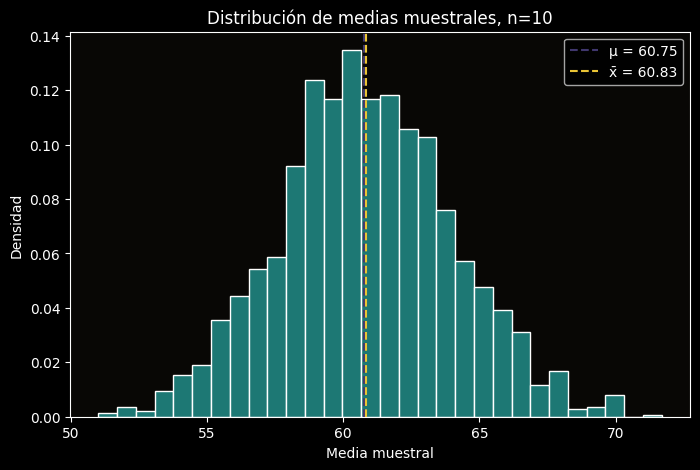

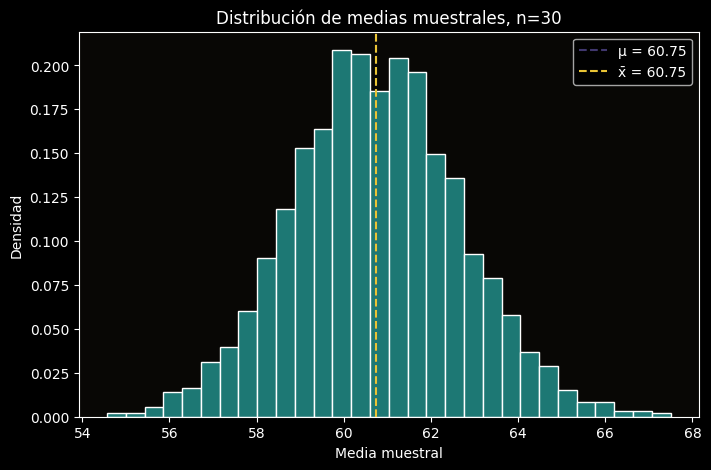

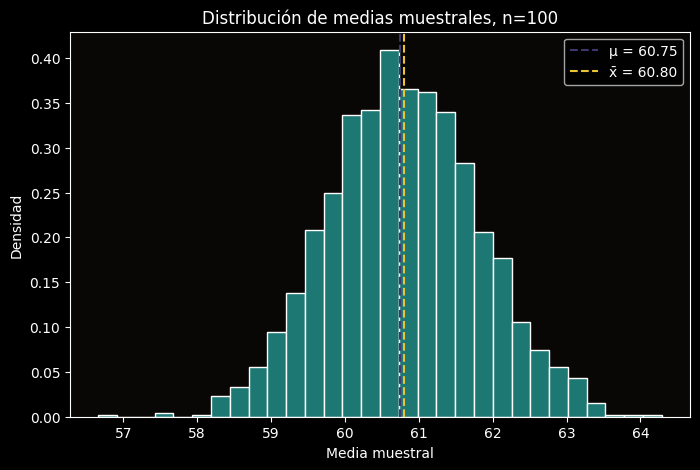

In [ ]:
df_muestras_edades = muestras_numericas('Age',2026)

In [ ]:
bins = len(df.Age)**0.5
bins

44.721359549995796

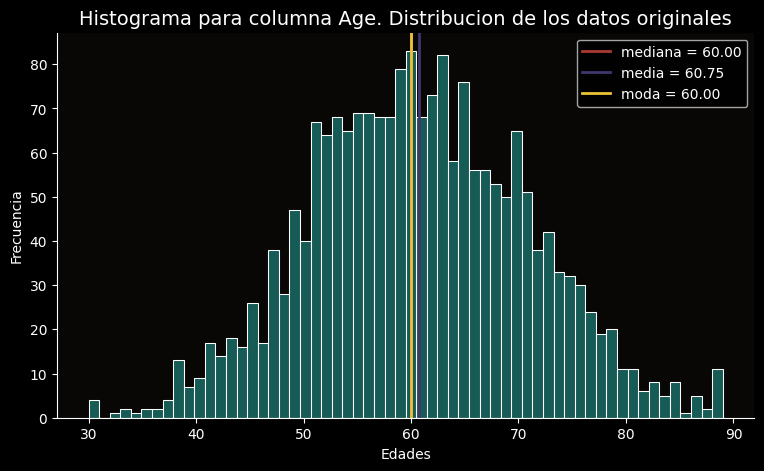

In [ ]:
histograma(df,'Age','Edades',title_labels="Distribucion de los datos originales", bins=60)

In [ ]:
cuantitativo(df,'Age')

Se selecciona la variable cuantitativa Age:

--------------------------------------------------
- Resultados del primer cuartil (Q1):  53.0

- Resultados del tercer cuartil (Q3):  68.0

- Rango Intercuartil (IQR):  15.0
--------------------------------------------------
Límite inferior conforme a regla del rango IQR (1.5 veces IQR):  30.50
Cantidad de resultados atípicos debajo de rango 1.5 veces IQR: 4
| Patient_ID   |   Age | Age_Group   | Country     | Cancer_Type   | Survived   |
|:-------------|------:|:------------|:------------|:--------------|:-----------|
| LC-0207      |    30 | 30-39       | New Zealand | SCLC          | No         |
| LC-0275      |    30 | 30-39       | Bangladesh  | NSCLC         | Yes        |
| LC-1040      |    30 | 30-39       | Qatar       | NSCLC         | No         |
| LC-1622      |    30 | 30-39       | Vietnam     | NSCLC         | No         |
--------------------------------------------------
Valor de mediana: 60.0
Valor de media: 60.75
Desvi

|   n |   media_de_medias |   sd_empirica_medias |   SE_teórico |   diferencia_con_mu |
|----:|------------------:|---------------------:|-------------:|--------------------:|
|  10 |           60.8341 |              3.19285 |      3.2681  |            0.08515  |
|  30 |           60.7452 |              1.93591 |      1.88684 |           -0.0038   |
| 100 |           60.7966 |              1.00764 |      1.03347 |            0.047635 |

---
#### Preguntas de interpretación:


##### Centro de distribuciones muestrales

`μ (60.75) y media_de_medias`

1. ¿Son exactamente iguales?
> No, Son cercanos pero no iguales.

2. ¿Son cercanas?
> Sí, aunque el valor determinado con n=30 es el más cercano de los 3 (60.7452)

3. ¿Por qué no esperas que sean idénticas en una simulación finita?
> Porque está suceptible a la aleatoriedad generada a partir del muestreo en cada punto.

---
##### Variabilidad
$$ n = 10, n = 30, n = 100 $$

1. ¿Cuál presenta mayor dispersión?
> La que tiene el valor de n=10, con un valor de 3.19825

2. ¿Cuál presenta menor dispersión?
> El valor de n=100, con una dispersión de 1.00764

3. ¿Qué efecto tiene aumentar n?
> Los valores tienden a ser más cercanos al valor de la media y presentan menor dispersión.

---

##### Error estándar

1. ¿Los valores empíricos y teóricos son cercanos?
> Sí, son cercanos variando únicamente por unos cuantos decimales.

2. ¿Qué evidencia proporciona la simulación sobre la fórmula del error estándar?
> La evidencia empírica nos sirvió para demostrar que la distribución de resultados proporciona evidencia de lo establecido por medio de la fórmula del error estándar.

3. Si se cuadruplica el tamaño de la muestra, ¿qué debería ocurrir aproximadamente con el error
estándar?
> Tal como lo vimos al aumentar el tamaño de n, el error estándar sería menor, lo que indicaría menor dispersión teórica de los datos.

4. Si simplemente se duplica n, ¿el error estándar se reduce a la mitad? Explica.
> no, porque la relación se da entre la raíz cuadrada de n y no sobre el valor de n, por lo que en teoría disminuiría a la raíz cuadrada del valor que se incremente.

---
##### Forma y Teorema Central del Límite

1. ¿La distribución original es aproximadamente simétrica o presenta asimetría?
> Puesto que el valor de la media (60.75) y el de la mediana (60.00) son cercanos podemos indicar que la distribución original de los datos es aproximadamente simétrica.\
No se observa una asimetría en la forma del pico pero sí podemos observar en el análisis posterior que obtuvimos valores atípicos sobre el límite inferior.
 2. ¿Qué ocurre con la forma de la distribución de las medias al aumentar n?
 > Lo que se observa principalmente es que se obtiene una forma simétrica de campana y esta se estrecha al aumentar n.

 3. ¿Los datos individuales se volvieron normales?
 > No, el ejercicio aplicado fue solamente relacionado con la evaluación de la media, pero los datos originales mantienen su distribución original.

 4. ¿Qué distribución es la que puede aproximarse progresivamente a una normal?
 > La distribución t-student, la cual parte de la distribución normal pero que es evaluada con estadísticos.

5. ¿Cuál es la diferencia entre la distribución de los datos originales y la distribución muestral de x̄?
> Creo que la distribución muestral de x̄ tiene la principal característica de modificarse conforme aumenta el número de n, en tanto que la distribución original debe su comportamiento a las características generales de la población.




## Conclusión de la parte aplicada:
---
Para el ejercicio seleccione la variable `Treatment`, la cual describe el tipo de tratamiento que lleva a cabo un paciente de pulmón.
La evaluación de la proporción poblacional arrojó un resultado de 0.205, en tanto que en las muestras tomadas la proporción se mantuvo por encima en un rango de 0.22 a 0.28.\
La variación para la variable numérica fue para la variable `Age`, la cual describe la distribución de frecuencias de las edades para los pacientes con cáncer de pulmón registrados en nuestro Dataset.
El valor de la media obtenido para dicha variable fue de 60.75 años, en tanto que la desviación estándar es de 10.34.\
Observamos que para la muestra generada a partir de los datos el valor de la media es mayor al obtenido de en la media poblacional. Auque es cercano (62.28), la variación del resultado puede explicarse por medio de la aleatoriedad en a la generación de la muestra.\
De igual manera, ejecutamos el ejericio de observar una distribución de media en función del tamaño de muestreo (n). En este observamos que los tres valores se acercaron a la media poblacional, siendo el más cercano cuando n=30 (60.7452).\
Asimismo, encontramos que el resultado del error estándar era aproximado al de la desviación estándar de los resultados, por lo que se pudo comprobar de manera empírica.\
Una limitación que pudiera indicarse en este ejercicio es que el aumentar la cantidad de muestras o la estrategia del muestreo no modifica la distribución de los datos originales, por lo que seguirá siendo suceptible al efecto de valores atípicos.\
Una afirmación que no pudiera sostener es que los tamaños más grandes de las muestras sean más representativos o corrijan ciertos parámetros observados a partir de las muestras. Posiblemente una variación en las técnicas de muestreo más que en el estado de aleatoriedad hubiera generado resultados más cercanos a los observados en la población.De igual manera, no observamos que algunas de las muestras fuera exactamente igual al parámetro de la media.

###